# Boundedness diagnostics: hooks, derivations, and the post-run accessor

This notebook demonstrates the full boundedness toolkit built on the hook system:

- the pure functions **`bound_mask`** (iterative unbinding) and **`reconstruct_mask`**;
- the **`BoundednessHook`** — a transition log (always on), *derived* boolean diagnostics
  (`fraction`, `n_bound`, `n_unbound`, `mask_at`, `history`), opt-in coordinate
  reductions (`track=`), and per-flip payloads (`capture_transitions=`);
- **`BoundKinematics`** — a separate O(N) capture hook at its own cadence;
- a **custom user hook** built the same way (calling `state.bound_mask`);
- the **shared-computation cache** (one `bound_mask` per fire, many consumers);
- the post-run **`Sim.boundedness`** accessor.

Scenario: a Plummer progenitor on a near-circular orbit in the Milky Way, dissolving into a
tidal stream.

## 1. Setup

In [38]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from galpy.potential import MWPotential2014

from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy
from tambora.tools.util.units import KPCGYR_TO_KMS
from tambora.dynamics.diagnostics import bound_mask, reconstruct_mask
from tambora.dynamics.hooks import (Hook, BoundednessHook, BoundKinematics,
                                    EveryNSteps, EveryOutput)

EPS = 0.05                                     # softening [kpc]
host = MWPotential2014[2]                       # NFW halo
host.turn_physical_on(ro=8 * u.kpc, vo=220 * u.km / u.s)

N = 10_000
R = 15.0
vc = host.vcirc(R * u.kpc, quantity=True).to(u.km / u.s).value
pos, vel, mass = mkPlummer_galpy(m=1e8, b=0.25, n=N,
                                 center_pos=[R, 0, 0], center_vel=[0, vc*0.75, 0])

sim = Sim()
sim.add_external_pot(host)
sim.add_particles('sat', pos, vel, mass)
print(f"{N} particles placed at R = {R} kpc, vc = {vc:.1f} km/s")

10000 particles placed at R = 15.0 kpc, vc = 149.1 km/s


## 2. The pure function `bound_mask` (and `reconstruct_mask`)

`bound_mask` is a plain array-in function — the single source of truth shared by the hook and
the accessor. Here we call it directly on the initial conditions (in internal units, which the
component accessor gives us via `return_internal=True`).

In [39]:
pos0 = sim.sat.pos(0, return_internal=True)     # kpc
vel0 = sim.sat.vel(0, return_internal=True)     # kpc/Gyr (internal)
mass0 = sim.mass[sim._slices['sat']]            # Msun

mask0 = bound_mask(pos0, vel0, mass0, eps=EPS, method='falcON', theta=0.6)
print(f"initially bound: {mask0.sum()} / {N}")

initially bound: 10000 / 10000


In [40]:
# reconstruct_mask replays a transition log from an initial mask.
init = np.array([True, True, False])
events = [(2, 0.5, +1),        # particle 2 becomes bound at t=0.5
          (0, 1.0, -1)]        # particle 0 becomes unbound at t=1.0
for t in (0.0, 0.5, 1.0):
    print(f"t={t}: {reconstruct_mask(init, events, t)}")

t=0.0: [ True  True False]
t=0.5: [ True  True  True]
t=1.0: [False  True  True]


## 3. Registering hooks

We add three hooks, all targeting `'sat'` with the same `eps`/`method` so they **share** the
cached `bound_mask`:

- **`BoundednessHook`** at a fine cadence (`EveryNSteps(5)`) — tracks `com`/`com_vel`/`dispersion`
  and captures `pos`/`vel` at every transition.
- **`BoundKinematics`** at a coarse cadence (`EveryOutput`) — the O(N) capture.
- **`FullMaskRecorder`** — a *custom user hook* (fine cadence) that stores the full mask each fire.
  It exists only to (a) show how a user writes their own hook, and (b) serve as ground truth for
  the reconstruction check later.

We instrument `bound_mask` with a call counter to prove the cache dedup.

In [41]:
# Custom hook: store the full bound mask each fire. The whole extension
# contract is 'subclass Hook, call state.bound_mask, store what you want'.
class FullMaskRecorder(Hook):
    default_cadence = EveryNSteps(5)
    def __init__(self, component, eps):
        self.component, self.eps = component, eps
        self.t, self.masks = [], []
    def __call__(self, state):
        self.t.append(state.t)
        self.masks.append(state.bound_mask(self.component, eps=self.eps).copy())

bh = BoundednessHook('sat', eps=EPS, track=('com', 'com_vel', 'dispersion'),
                     capture_transitions=('pos', 'vel'))
bk = BoundKinematics('sat', eps=EPS)
fm = FullMaskRecorder('sat', eps=EPS)

sim.add_hook(bh, cadence=EveryNSteps(5))       # fine booleans + reductions
sim.add_hook(bk, cadence=EveryOutput())        # coarse O(N) capture
sim.add_hook(fm, cadence=EveryNSteps(5))       # custom, ground truth

# --- instrument bound_mask to count actual computations ---
import tambora.dynamics.diagnostics as _diag
_calls = {'n': 0}
_orig = _diag.bound_mask
def _counting(*a, **k):
    _calls['n'] += 1
    return _orig(*a, **k)
_diag.bound_mask = _counting

sim.run(t_end=2.0, dt=0.005, dt_out=0.05, method='falcON', eps=EPS, theta=0.6)

_diag.bound_mask = _orig                         # restore
invocations = len(bh.t) + len(bk.t) + len(fm.t)
print(f"\nbound_mask actually computed:   {_calls['n']} times")
print(f"total hook invocations:         {invocations}")
print(f"saved by the shared-step cache: {invocations - _calls['n']} recomputations")

100%|██████████| 400/400 [00:17<00:00, 23.47it/s, n_bound(sat)=6410]


bound_mask actually computed:   81 times
total hook invocations:         203
saved by the shared-step cache: 122 recomputations


## 4. Cache dedup — one computation, many consumers

`bound_mask` ran **once per fire step**, not once per hook. On steps where several hooks fire
(they all target the same `component`/`eps`), the first to run computes the mask and caches it on
the `StepState`; the rest get a cache hit. That's what makes "one `bound_mask` computation"
hold even across independently-cadenced hooks.

## 5. Derived boolean diagnostics

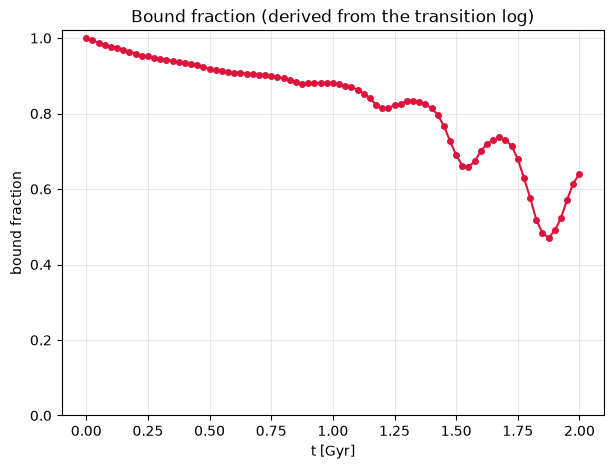

n_bound at first 5 fires:  [10000  9940  9873  9821  9775]
n_unbound at first 5 fires: [  0  60 127 179 225]


In [42]:
t = np.array(bh.t)
plt.figure(figsize=(7, 5))
plt.plot(t, bh.fraction(), 'o-', c='crimson', ms=4)
plt.xlabel('t [Gyr]'); plt.ylabel('bound fraction')
plt.title('Bound fraction (derived from the transition log)')
plt.ylim(0, 1.02); plt.grid(alpha=0.3); plt.show()

print("n_bound at first 5 fires: ", bh.n_bound()[:5])
print("n_unbound at first 5 fires:", bh.n_unbound()[:5])

## 6. Lossless reconstruction + memory

The hook stores only the initial mask + transition events. We reconstruct the full mask history
and compare it to the `FullMaskRecorder` ground truth — they must be identical — then compare
storage sizes.

In [43]:
reconstructed = bh.history()                    # (n_fires, N) from the transition log
ground_truth = np.array(fm.masks)               # (n_fires, N) stored directly

print("reconstruction == ground truth:", np.array_equal(reconstructed, ground_truth))

n_events = len(bh.events)
n_fires = len(bh.t)
print(f"\nstored transition events:        {n_events}")
print(f"full mask history would store:   {N * n_fires} booleans")
print(f"compression:                     {N * n_fires / max(n_events, 1):.1f}x fewer entries")

reconstruction == ground truth: True

stored transition events:        58580
full mask history would store:   810000 booleans
compression:                     13.8x fewer entries


## 7. Transition events: when and where

Because we passed `capture_transitions=('pos', 'vel')`, each event carries the particle's
position and velocity at the moment it flipped. Event layout: `(idx, time, direction, pos, vel)`.
Below: the unbinding events (`direction == -1`), coloured by the time they left.

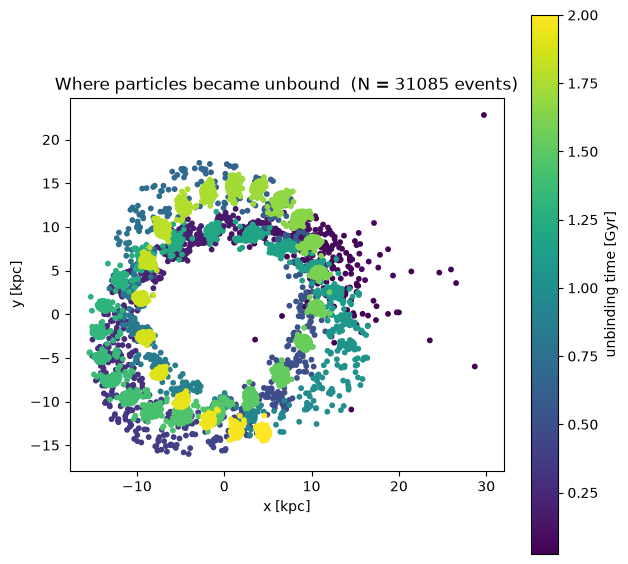

In [50]:
unbind = bh.transitions(direction=-1)           # events where particles became unbound
ux = np.array([e[3][0] for e in unbind])        # e[3] is the captured position
uy = np.array([e[3][1] for e in unbind])
ut = np.array([e[1] for e in unbind])

plt.figure(figsize=(7, 7))
sc = plt.scatter(ux, uy, c=ut, cmap='viridis', s=10)
plt.colorbar(sc, label='unbinding time [Gyr]')
plt.gca().set_aspect('equal'); plt.xlabel('x [kpc]'); plt.ylabel('y [kpc]')
plt.title(f'Where particles became unbound  (N = {len(unbind)} events)')
plt.show()

## 8. Tracked reductions: bound COM and velocity dispersion

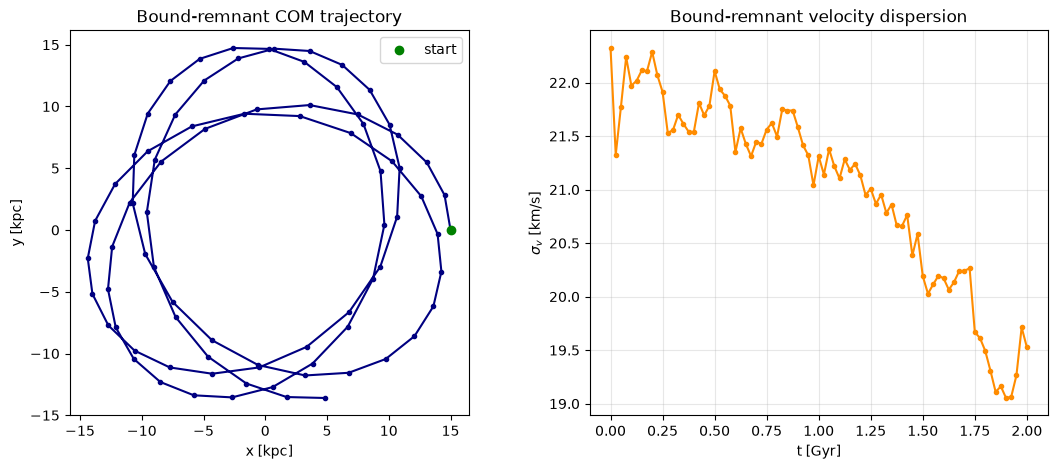

In [45]:
com = np.array(bh.com)                           # (n_fires, 3) kpc
disp = np.array(bh.dispersion) * KPCGYR_TO_KMS   # km/s

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(com[:, 0], com[:, 1], 'o-', ms=3, c='navy')
ax[0].scatter(*com[0, :2], c='g', zorder=5, label='start')
ax[0].set_aspect('equal'); ax[0].set_xlabel('x [kpc]'); ax[0].set_ylabel('y [kpc]')
ax[0].set_title('Bound-remnant COM trajectory'); ax[0].legend()

ax[1].plot(t, disp, 'o-', ms=3, c='darkorange')
ax[1].set_xlabel('t [Gyr]'); ax[1].set_ylabel(r'$\sigma_v$ [km/s]')
ax[1].set_title('Bound-remnant velocity dispersion'); ax[1].grid(alpha=0.3)
plt.show()

## 9. `BoundKinematics`: bound pos/vel at a coarse cadence

The separate capture hook stores the full phase space of the bound set at its own (coarser)
cadence. The stored arrays are ragged — the bound count shrinks over time.

BoundKinematics fires: 41
bound counts (from stored pos): [10000, 9873, 9775, 9696, 9590, 9512, 9442, 9392, 9344, 9279, 9189, 9125, 9087, 9055, 9024, 8989, 8930, 8841, 8797, 8815, 8797, 8741, 8627, 8406, 8142, 8219, 8340, 8313, 8137, 7671, 6897, 6577, 7002, 7294, 7309, 6792, 5767, 4836, 4904, 5721, 6410]


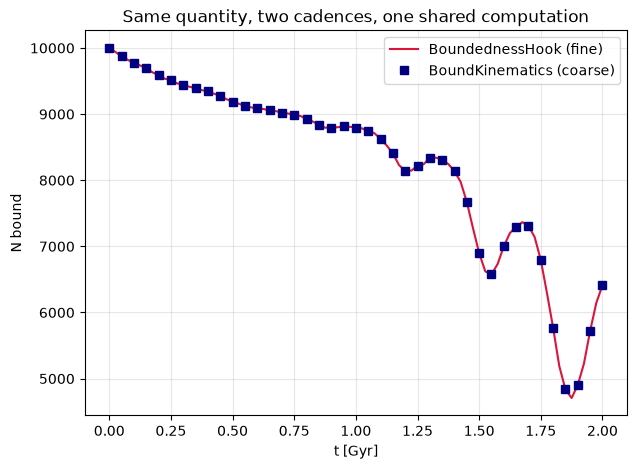

In [46]:
print("BoundKinematics fires:", len(bk.t))
print("bound counts (from stored pos):", [p.shape[0] for p in bk.pos])

plt.figure(figsize=(7, 5))
plt.plot(bh.t, bh.n_bound(), '-', c='crimson', label='BoundednessHook (fine)')
plt.plot(bk.t, [p.shape[0] for p in bk.pos], 's', c='navy', label='BoundKinematics (coarse)')
plt.xlabel('t [Gyr]'); plt.ylabel('N bound'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Same quantity, two cadences, one shared computation'); plt.show()

## 10. Post-run accessor `Sim.boundedness`

The same physics, run on stored snapshots after the fact. It agrees with the live hook.

In [47]:
acc_mask = sim.boundedness('sat', t=-1, eps=EPS, method='falcON', theta=0.6)
print("Sim.boundedness(-1):", int(acc_mask.sum()), "bound")
print("hook live last:     ", bh.n_bound()[-1], "bound")
print("agree:", int(acc_mask.sum()) == bh.n_bound()[-1])

print("\nn_bound at snapshot indices 0, 5, 10, -1:")
for i in (0, 5, 10, -1):
    print(f"  t index {i:>3}: {int(sim.boundedness('sat', t=i, eps=EPS).sum())}")

Sim.boundedness(-1): 6410 bound
hook live last:      6410 bound
agree: True

n_bound at snapshot indices 0, 5, 10, -1:
  t index   0: 10000
  t index   5: 9512
  t index  10: 9189
  t index  -1: 6410


## 11. The stream

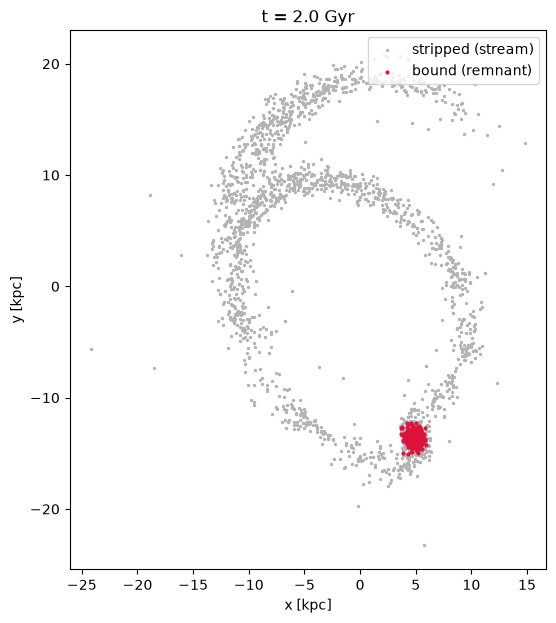

In [48]:
x, y = sim.sat.x(-1), sim.sat.y(-1)             # final snapshot, physical kpc
plt.figure(figsize=(7, 7))
plt.scatter(x[~acc_mask], y[~acc_mask], s=2, c='0.7', label='stripped (stream)')
plt.scatter(x[acc_mask],  y[acc_mask],  s=4, c='crimson', label='bound (remnant)')
plt.gca().set_aspect('equal'); plt.xlabel('x [kpc]'); plt.ylabel('y [kpc]')
plt.title(f't = {sim.times[-1]:.1f} Gyr'); plt.legend(loc='upper right'); plt.show()

## Summary

- **`bound_mask` / `reconstruct_mask`** — pure functions; `bound_mask` backs the live hook and the
  post-run accessor, `reconstruct_mask` replays the transition log.
- **`BoundednessHook`** — always logs transitions; `fraction`/`n_bound`/`n_unbound`/`mask_at`/`history`
  are derived; `track=` adds stored coordinate reductions; `capture_transitions=` attaches per-flip
  payloads. Reconstruction from the log was verified lossless against a full-mask ground truth, at a
  large storage saving.
- **`BoundKinematics`** and the custom **`FullMaskRecorder`** — separate hooks at their own cadences,
  sharing the cached `bound_mask` for free.
- **`Sim.boundedness`** — the post-run accessor, agreeing with the live result.